# Real estate price analysis, Mumbai

Combined EDA + cleaning + modeling notebook. Replaces the earlier split (`eda.ipynb` + `deduplication-modelling.ipynb`).

## Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

## 1. Load data

In [6]:
data = pd.read_csv(r"..\data\csv\magicbricks_mumbai_20260824_172759.csv")
print(f"rows, cols: {data.shape}")
data.head(2)

rows, cols: (1196, 278)


,OwnershipTypeD,ac,acD,achTdS,achTm,achTmS,actualOwner,adCn,ad_text,adroomD,agComCt,agentContinuityStr,agentDetailUrl,agentReraState,agtCerStatus,agtCrSt,allImgCt,allImgPath,amenFacingD,amenities,ampDesc,appExc,appExcProp,appExcRe,appSub,appVer,appovedAuthC,attrImg,auto_desc,availUnit,availableFrom,avlAfter,b2cCardEligibility,balconiesD,bathD,bcp,bd,bedroomD,bookingAmtExact,brfdesc,brokerConnect,buyerCountbyPsm,cScore,ca,caCompNameD,caSqFt,carpAreaUnit,carpetArea,catAdd1,cg,cntvl,comFlag,comPantry,companyname,contName,covAreaUnit,covAreaUnitDesc,coverAreaUnitD,coveredArea,cowDays,cpmp,crisilNoOfEmployees,crisilOpSinceYear,crisilRv1CtBy,crisilStarRating,ct,ctCurr,ctLast,ctName,ctVerifd,ctaDetailBean,ctaRuleId,dImgRf,dImgSrc,dealDesc,defaultAdddressGoogle,devId,devName,deviceType,dimD,dsla,dtldesc,dues,ecd,encId,enc_Id,endDateT,endDt,exc,facingD,floorCsntrAllowed,floorD,floorNo,flooringTyD,floors,furnished,furnishedD,gateComm,grpBky1,grpBky2,grpBky3,grpBky4,grpBky5,grpBky6,grpBky7,iTarget,iba,id,image,imageCount,imageDate,imgCt,imgUrl,infraStatusList,investorguide,investorlisting,isAdvertiserOfThisListingAOwnerAndUnPaid,isCornerPlot,isExcl,isLuxury,isLuxuryServiceAvailable,isPaidUser,isPreferred,isPrimeLocProp,isProjProp,isRera,isReraAgent,isThisListingAPremiumOnly,isVis,isprimeListingType,lCct,lCtDate,la,landAreaUnit,landAreaUnitD,landmark,landmarkDetails,lastAccessDate,legalDocStatusList,lmtDName,loc,locSeoName,localityPhoto,lt,ltOther,ltcoordGeo,luxAmenMap,luxAmenities,luxAmenitiesD,maintenanceCharges,maintenanceD,maxPrice,minPrice,modifiedDate,modstat,moisd,nOs,newLaunch,newUrl,noBfCt,nonluxAmenMap,nriPref,oid,oname,opSn,opSnD,operatingSinceYear,pCct,pEmailuuid,pSc,parkingD,pbrk,pbrkp,pcTcCt,pckCon,pd,personType,pfAgCg,pglmtkey,pkg,pkgid,pl,plgdtldesc,pmtLat,pmtLong,pmtSource,pmtTCabin,pmtUsp,pmtUsp1,pmtUsp2,pmtUsp2Wap,pmtUspWap,pmtdesc_hi,pmtmtrendPercentage,pmtvLink,possBy,possStatusD,postDateT,postedEditedLabel,postedLabelD,powerStatusD,pp,ppd,ppdL,price,priceD,prjHl1,prjLtHl1,prjSrc,prjid,prjname,prm,projectSocietyLink,propCat,propImg,propTypeD,propertyImageNew,propertyTitle,ps,psmAdd,psmAmenDesc,psmImage,psmImgCt,psmMD,psmUspImgMob,psmUspImgMobnew,psmUspImgWeb,psmVideos,psmapproved,psmid,rEcd,ranPropImg,randomImg,rdWidth,reraId,reraValidity,sVisMaxDt,sVisMinDt,sdp,seoDesc,seoLtSc,seoPsmDt,seoURL,showFreshPropLocked,showupfront,sid,sipro,siteVisitProp,smartDiaryApiTag,smouuid,soc,sortCode,sortCode1,sortCode1b,sortCode22,sortCode26,sortCode44,sqFtPrD,sqFtPrice,st,supV,sv,svProp,taImg,tag,tagWap,tenantsPreference,th,tmsrt,transType,transactionTypeD,ty,ubicnt,url,userType,wapImgUrl,wapImgUrl1,waterStatus
0,NaN,11655.0,15 to 20 years,149,82,82,20435305,NaN,Sale Agent Mumbai Maharashtra India Sarwar A...,Store,NaN,NaN,/bricks/property-agent-details/broker--in-Mumb...,NaN,NaN,NaN,9.0,"[""https://img.staticmb.com/mbphoto/property/cr...","Garden/Park, Main Road",12201 12202 12203 12209 12215 12216 12218 1222...,Multistorey apartment is available for rent. I...,N,NaN,NaN,Y,643.0,NaN,NaN,"2 BHK, Multistorey Apartment is available for ...",NaN,NaN,NaN,False,1,3,NaN,11701,2,NaN,NaN,Y,NaN,74,800.0,Sarwar Alam,800.0,NaN,NaN,NaN,b,60.0,N,NaN,NaN,NaN,12800.0,Sq-ft,Sq-ft,800,0,NaN,NaN,NaN,NaN,NaN,4320,95.0,0.0,Mumbai,N,"{""ctapid"": 0, ""ctaid"": 101, ""platform"": 0, ""cn...",NaN,PROP391246851,10505.0,NaN,"Mumbai, Maharashtra",NaN,NaN,and,NaN,NaN,Multistorey apartment is available for rent. I...,NaN,20260824,8WeYBqE0hkJzpSvf+uAgZw==,8WeYBqE0hkLwLxvilO7ZNg==,2026-10-21T18:30:00.000Z,"Oct 22, '26",NaN,South -West,NaN,6 of 10 Floor,6,Marble,10.0,11900.0,Furnished,NaN,0,0,0,0,0,0,0,NaN,X,86135065,https://img.staticmb.com/mbphoto/property/crop...,9.0,2026/Aug/23,9,NaN,NaN,N,N,True,NaN,NaN,F,False,Y,NaN,Y,N,NaN,NaN,True,N,True,0,NaN,NaN,NaN,NaN,"Market ,shopping mall ,jogging track ,school ,...","[""19210|Bandra Railway Station (W) Bus Stop||1...",2026-08-22T18:30:00.000+00:00,NaN,Bandra West,78839.0,Bandra West,0,78839.0,NaN,"19.055229,72.83

## 2. Select needed columns

In [7]:
with open('neededcols.txt', 'r') as f:
    cols_to_keep = f.read().split(',')

existing_cols = [c for c in cols_to_keep if c in data.columns]
missing_requested = [c for c in cols_to_keep if c not in data.columns]
if missing_requested:
    print(f"requested but not in this scrape: {missing_requested}")

data_needed_cols = data[existing_cols].copy()
data_needed_cols.shape

(1196, 66)

In [8]:
imp_cols = ['acD', 'price', 'sqFtPrice', 'bedroomD', 'bathD', 'balconiesD', 'carpetArea',
            'coveredArea', 'floorNo', 'floors', 'furnishedD', 'facingD', 'amenFacingD',
            'propTypeD', 'transactionTypeD', 'possStatusD', 'ecd', 'ctName', 'locSeoName',
            'prjname', 'landmark', 'lmtDName', 'ltcoordGeo', 'luxAmenitiesD', 'parkingD',
            'waterStatus', 'powerStatusD', 'maintenanceCharges', 'maintenanceD', 'flooringTyD',
            'reraValidity', 'OwnershipTypeD', 'tenantsPreference', 'postDateT',
            'propertyTitle', 'adroomD']

working_dataset = data_needed_cols[[c for c in imp_cols if c in data_needed_cols.columns]]
working_dataset.shape

(1196, 36)

## 3. Data quality assessment

In [9]:
null_pct = (working_dataset.isnull().sum() / len(working_dataset) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]
print(f"rows, cols: {working_dataset.shape}\n")
print("% missing per column:")
null_pct.round(1)

rows, cols: (1196, 36)

% missing per column:


maintenanceCharges    75.3
maintenanceD          71.4
adroomD               70.4
parkingD              70.2
powerStatusD          68.2
waterStatus           68.1
balconiesD            67.6
flooringTyD           65.6
landmark              65.6
amenFacingD           63.4
facingD               60.6
reraValidity          60.3
OwnershipTypeD        59.5
luxAmenitiesD         45.7
acD                   28.3
prjname               25.7
floors                16.8
floorNo               16.8
sqFtPrice             14.8
carpetArea            14.5
coveredArea           12.6
locSeoName             9.7
ltcoordGeo             5.2
lmtDName               5.2
price                  3.6
possStatusD            3.6
furnishedD             1.6
bathD                  0.9
transactionTypeD       0.1
dtype: float64

Columns missing more than 70% of their values don't carry enough signal to use as predictors, dropping them rather than imputing noise. The exact columns and count depend on this run's data, printed below instead of assumed.

In [10]:
high_missing = null_pct[null_pct > 70].index.tolist()
print(f"dropping ({len(high_missing)} columns, >70% missing): {high_missing}")

df = working_dataset.drop(columns=high_missing).copy()
df.shape

dropping (4 columns, >70% missing): ['maintenanceCharges', 'maintenanceD', 'adroomD', 'parkingD']


(1196, 32)

## 4. Cleaning

In [11]:
# floorNo mixes numbers with the string 'Ground' -> treat Ground as floor 0
df['floorNo'] = df['floorNo'].replace({'Ground': '0'})
df['floorNo'] = pd.to_numeric(df['floorNo'], errors='coerce')

# ecd is an int date like 20260813 -> proper datetime
df['ecd'] = pd.to_datetime(df['ecd'].astype(str), format='%Y%m%d', errors='coerce')

# postDateT is an ISO timestamp string -> datetime
df['postDateT'] = pd.to_datetime(df['postDateT'], errors='coerce')

# ltcoordGeo is "lat,long" packed into one string -> split into two numeric cols
coords = df['ltcoordGeo'].str.split(',', expand=True)
df['latitude'] = pd.to_numeric(coords[0], errors='coerce')
df['longitude'] = pd.to_numeric(coords[1], errors='coerce')
df = df.drop(columns=['ltcoordGeo'])

# carpetArea / coveredArea sometimes carry thousands-separator commas
# (e.g. "15,559") on larger properties, strip before converting
for col in ['carpetArea', 'coveredArea']:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')

df[['floorNo', 'ecd', 'postDateT', 'latitude', 'longitude', 'carpetArea', 'coveredArea']].head()

,floorNo,ecd,postDateT,latitude,longitude,carpetArea,coveredArea
0,6.0,2026-08-24,2026-08-23 14:55:10+00:00,19.055229,72.830829,NaN,800.0
1,12.0,2026-05-18,2026-05-18 06:26:13+00:00,NaN,NaN,NaN,675.0
2,NaN,2026-08-24,2026-08-24 06:56:11+00:00,19.192963,72.822057,300.0,NaN
3,NaN,2026-08-24,2026-08-24 06:53:29+00:00,19.091147,72.882871,120.0,220.0
4,1.0,2026-05-27,2026-05-26 18:00:39+00:00,19.089349,72.886068,NaN,300.0


In [12]:
# acD is a bucketed string like '10 to 15 years' -> map to a numeric midpoint.
# Mapping covers every label seen across all three scrapes so far, printing
# any unmapped label rather than silently producing NaN for a new one.
age_map = {
    'New Construction': 0,
    '0 to 1 years': 0.5,
    'Less than 5 years': 3,
    '1 to 5 years': 3,
    '5 to 10 years': 7.5,
    '10 to 15 years': 12.5,
    '15 to 20 years': 17.5,
    'Above 20 years': 25,
    '20+ years': 25,
}
unmapped = set(df['acD'].dropna().unique()) - set(age_map.keys())
if unmapped:
    print(f"unmapped acD labels, add these to age_map: {unmapped}")

df['property_age_yrs'] = df['acD'].map(age_map)

In [13]:
# bedroomD / bathD come in as strings, '> 10' needs an explicit numeric stand-in
for col in ['bedroomD', 'bathD']:
    df[col] = df[col].replace({'> 10': '10'})
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[['bedroomD', 'bathD']].describe()

,bedroomD,bathD
count,1196.000000,1185.000000
mean,2.840301,2.813502
std,1.555796,1.456516
min,1.000000,1.000000
25%,2.000000,2.000000
50%,3.000000,2.000000
75%,4.000000,3.000000
max,10.000000,10.000000


## 5. Price integrity check

The Aug 24 scrape has a handful of rows where `price` is corrupted, in some cases inconsistent with `sqFtPrice x carpetArea`, and in one case the raw scraped `priceD` text itself is nonsensical ("145100450.40 Cr", more than India's GDP for a 1BHK). This isn't a cleaning artifact, it's present in the raw CSV.

Two checks, since neither alone catches everything:
- **Ratio check**: where both `sqFtPrice` and `carpetArea` exist, `price` should roughly equal their product. Flagging anything off by more than 3x or under 0.3x (a loose band, real listings can legitimately vary this much due to amenities/floor/view, so this only catches gross mismatches).
- **Absolute cap, applied to every row**: a few listings have `price` *and* `sqFtPrice` corrupted together by the same bug, they agree with each other while both being absurd, so the ratio check alone lets them through. ₹200 Cr is far above even Mumbai's most expensive confirmed listings in this data, applying it universally catches these regardless of whether the ratio looks clean.

In [14]:
RATIO_LOW, RATIO_HIGH = 0.3, 3.0
ABSOLUTE_CAP = 2_000_000_000  # 200 Cr

checkable = df['sqFtPrice'].notna() & df['carpetArea'].notna() & (df['sqFtPrice'] > 0) & (df['carpetArea'] > 0)
implied_price = df['sqFtPrice'] * df['carpetArea']
ratio = df['price'] / implied_price

flag_ratio = checkable & ((ratio > RATIO_HIGH) | (ratio < RATIO_LOW))
flag_absolute = df['price'] > ABSOLUTE_CAP  # applies regardless of checkable, catches jointly-corrupted pairs
flag_bad_price = flag_ratio | flag_absolute

print(f"{flag_ratio.sum()} rows flagged by ratio mismatch (price vs sqFtPrice x carpetArea)")
print(f"{flag_absolute.sum()} rows flagged by absolute cap (over Rs 200 Cr, checked or not)")
print(f"{flag_bad_price.sum()} rows total flagged, dropping\n")

df.loc[flag_bad_price, ['price', 'sqFtPrice', 'carpetArea', 'propertyTitle']]

6 rows flagged by ratio mismatch (price vs sqFtPrice x carpetArea)
5 rows flagged by absolute cap (over Rs 200 Cr, checked or not)
11 rows total flagged, dropping



,price,sqFtPrice,carpetArea,propertyTitle
289,2.543800e+10,NaN,805.0,2BHK Multistorey Apartment for New Property in...
295,1.511780e+10,2.690000e+07,562.0,2BHK Multistorey Apartment for New Property in...
299,2.981160e+10,2.730000e+07,780.0,2BHK Multistorey Apartment for New Property in...
809,2.579500e+07,5.500000e+04,4690.0,1BHK Multistorey Apartment for New Property in...
849,1.400000e+08,4.742500e+04,328.0,1BHK Residential House for Resale in Girgaon
851,7.670000e+09,1.180000e+07,420.0,1BHK Multistorey Apartment for New Property in...
852,1.451005e+15,3.463018e+12,NaN,1BHK Multistorey Apartment for Resale in Build...
856,9.500000e+08,6.105800e+04,419.0,1BHK Multistorey Apartment for Resale in Jadei...
929,1.850000e+07,1.682000e+03,3000.0,4BHK Villa for Resale in Virar East
1118,6.000000e+07,1.200000e+04,1593.0,9BHK Residential House for Resale in Daulat Na...


In [15]:
df = df[~flag_bad_price].copy()
print(f"{df.shape[0]} rows remain after dropping contaminated price rows")

1185 rows remain after dropping contaminated price rows


### 5b. Per-sqft ceiling

Some rows have `price` *and* `sqFtPrice` inflated together by roughly the same factor, they stay internally consistent (ratio checks out) while both being absurd. A 2BHK in Jogeshwari West or Mira Road at ₹1.5 to 2 lakh per sqft isn't a data-quality edge case, it's off by an order of magnitude, even Mumbai's most expensive confirmed stretches (Malabar Hill, Altamount Road) rarely clear ₹200000/sqft in reported deals.

Splitting this into two bands rather than one hard cutoff:
- **Above ₹2.5L/sqft**: dropped outright, no realistic Mumbai listing in this data clears this.
- **₹1L to ₹2.5L/sqft**: kept, but flagged for manual review instead of guessed at. This band genuinely overlaps with legitimate ultra-luxury towers (Worli, Parel, Bandra West), dropping it outright risks cutting real high-end data, the same problem the original price-band scrape filter caused. Better to surface it than silently decide either way.

In [16]:
SQFT_PRICE_HARD_CAP = 250_000
SQFT_PRICE_REVIEW_FLOOR = 100_000

flag_sqft_extreme = df['sqFtPrice'] > SQFT_PRICE_HARD_CAP
print(f"{flag_sqft_extreme.sum()} rows over Rs {SQFT_PRICE_HARD_CAP:,}/sqft, dropping")
df[flag_sqft_extreme][['price', 'sqFtPrice', 'carpetArea', 'propertyTitle', 'locSeoName']]

6 rows over Rs 250,000/sqft, dropping


,price,sqFtPrice,carpetArea,propertyTitle,locSeoName
292,1.940000e+08,267586.0,668.0,2BHK Multistorey Apartment for New Property in...,Malad West
308,1.710000e+09,1900000.0,648.0,2BHK Multistorey Apartment for Resale in Rahej...,Powai
857,1.200000e+08,279720.0,309.0,1BHK Multistorey Apartment for Resale in Paras...,Andheri West
858,1.200000e+08,666667.0,180.0,1BHK Multistorey Apartment for New Property in...,Tardeo
1061,1.650000e+09,448980.0,2646.0,4BHK Multistorey Apartment for Resale in Raias...,Andheri West
1195,6.000000e+08,272727.0,2200.0,6BHK Multistorey Apartment for Resale in India...,Worli


In [17]:
df = df[~flag_sqft_extreme].copy()

df['review_high_psf'] = df['sqFtPrice'].between(SQFT_PRICE_REVIEW_FLOOR, SQFT_PRICE_HARD_CAP)
print(f"{df['review_high_psf'].sum()} rows kept but flagged for manual review "
      f"(Rs {SQFT_PRICE_REVIEW_FLOOR:,} to {SQFT_PRICE_HARD_CAP:,}/sqft)")
df.shape

24 rows kept but flagged for manual review (Rs 100,000 to 250,000/sqft)


(1179, 35)

### 5c. Structural sanity: carpet area vs bedroom count

In [18]:
sqft_per_bed = df['carpetArea'] / df['bedroomD']
checkable_config = df['carpetArea'].notna() & (df['bedroomD'] > 0)

# under 50 sqft per bedroom isn't a small flat, it's not physically possible
flag_impossible_config = checkable_config & (sqft_per_bed < 50)
print(f"{flag_impossible_config.sum()} rows physically impossible (under 50 sqft carpet area per bedroom), dropping")
df[flag_impossible_config][['price', 'carpetArea', 'bedroomD', 'propertyTitle']]

3 rows physically impossible (under 50 sqft carpet area per bedroom), dropping


,price,carpetArea,bedroomD,propertyTitle
360,4000000.0,72.0,3,3BHK Multistorey Apartment for Resale in Dev R...
868,3500000.0,25.0,4,4BHK Residential House for Resale in Kurla West
1099,20000000.0,90.0,10,10BHK Multistorey Apartment for Resale in Plaz...


In [19]:
df = df[~flag_impossible_config].copy()

# 50 to 100 sqft/bedroom is cramped but not impossible (older buildings,
# chawl-style units genuinely exist at this size in parts of Mumbai), flag rather than drop
df['review_tight_layout'] = checkable_config[~flag_impossible_config] & (sqft_per_bed[~flag_impossible_config].between(50, 100))
print(f"{df['review_tight_layout'].sum()} rows flagged as unusually tight layout, kept but worth a manual look")
df.shape

4 rows flagged as unusually tight layout, kept but worth a manual look


(1176, 36)

One row (10BHK new construction, `sqFtPrice = 0`) can't be verified either way, price alone (₹5 Cr) isn't unreasonable for that config and it's under the absolute cap, so it's kept rather than dropped on a guess. Flagged here for visibility rather than silently passed through.

In [20]:
unverifiable = df[~checkable.reindex(df.index, fill_value=False)]
print(f"{len(unverifiable)} rows kept but unverified (missing area/sqFtPrice data, price within sane bounds)")

328 rows kept but unverified (missing area/sqFtPrice data, price within sane bounds)


## 6. Deduplication

In [21]:
dupe_mask = df.duplicated(subset=['propertyTitle', 'price'], keep=False)
print(f"{dupe_mask.sum()} rows share both title and price with another row")
df[dupe_mask].sort_values(['propertyTitle', 'price'])[['propertyTitle', 'price', 'locSeoName', 'floorNo']].head(10)

67 rows share both title and price with another row


,propertyTitle,price,locSeoName,floorNo
812,1BHK Multistorey Apartment for New Property in...,25893000.0,Wadala,NaN
816,1BHK Multistorey Apartment for New Property in...,25893000.0,Wadala,NaN
850,1BHK Multistorey Apartment for New Property in...,126050000.0,Mira Road,1.0
859,1BHK Multistorey Apartment for New Property in...,126050000.0,Mira Road,1.0
631,1BHK Multistorey Apartment for Resale in,1400000.0,NaN,0.0
637,1BHK Multistorey Apartment for Resale in,1400000.0,NaN,0.0
622,1BHK Multistorey Apartment for Resale in Ganga...,2000000.0,Virar East,0.0
640,1BHK Multistorey Apartment for Resale in Ganga...,2000000.0,Virar East,0.0
840,1BHK Multistorey Apartment for Resale in Sprin...,55000000.0,Malad West,4.0
841,1BHK Multistorey Apartment for Resale in Sprin...,55000000.0,Malad West,4.0


Using `floorNo` as a tiebreaker, same title, same price, and same floor is a near-certain re-listing rather than a coincidence.

In [22]:
true_dupe_mask = df.duplicated(subset=['propertyTitle', 'price', 'floorNo'], keep='first')
print(f"dropping {true_dupe_mask.sum()} likely duplicate listings")
df = df[~true_dupe_mask].copy()
df.shape

dropping 26 likely duplicate listings


(1150, 36)

## 7. Feature engineering

In [23]:
df['price_per_sqft_calc'] = df['price'] / df['carpetArea']

df['days_since_posted'] = (pd.Timestamp.now(tz=df['postDateT'].dt.tz) - df['postDateT']).dt.days

furnish_order = {'Unfurnished': 0, 'Semi-Furnished': 1, 'Furnished': 2}
df['furnished_ord'] = df['furnishedD'].map(furnish_order)

df[['price_per_sqft_calc', 'days_since_posted', 'furnished_ord']].describe()

,price_per_sqft_calc,days_since_posted,furnished_ord
count,957.000000,1150.000000,1131.000000
mean,38594.341171,16.528696,0.761273
std,33100.358283,30.463243,0.783426
min,80.000000,0.000000,0.000000
25%,17336.152220,2.000000,0.000000
50%,32692.307692,3.000000,1.000000
75%,51229.508197,7.000000,1.000000
max,420654.911839,135.000000,2.000000


In [24]:
df['log_price'] = np.log(df['price'])
df['log_carpetArea'] = np.log(df['carpetArea'])

print("price skew:", round(df['price'].skew(), 2), "-> log_price skew:", round(df['log_price'].skew(), 2))
print("carpetArea skew:", round(df['carpetArea'].skew(), 2), "-> log_carpetArea skew:", round(df['log_carpetArea'].skew(), 2))

price skew: 3.73 -> log_price skew: -0.77
carpetArea skew: 2.62 -> log_carpetArea skew: 0.12


With the contaminated rows removed, price skew should now sit in a realistic range instead of being dragged by quadrillion-rupee entries.

## 8. Exploratory analysis

In [25]:
df[['price', 'carpetArea', 'coveredArea', 'floorNo', 'floors',
    'property_age_yrs', 'price_per_sqft_calc', 'days_since_posted']].describe()

,price,carpetArea,coveredArea,floorNo,floors,property_age_yrs,price_per_sqft_calc,days_since_posted
count,1.107000e+03,980.000000,1008.000000,963.000000,965.000000,829.000000,957.000000,1150.000000
mean,4.225361e+07,1114.651020,1380.913690,10.559709,19.921244,8.626659,38594.341171,16.528696
std,4.919674e+07,806.749974,1061.294599,11.142589,16.834440,8.399354,33100.358283,30.463243
min,1.000000e+05,108.000000,11.000000,0.000000,1.000000,0.000000,80.000000,0.000000
25%,1.040150e+07,582.250000,723.750000,3.000000,7.000000,3.000000,17336.152220,2.000000
50%,2.500000e+07,884.500000,1100.000000,7.000000,15.000000,7.500000,32692.307692,3.000000
75%,6.000000e+07,1400.000000,1695.500000,14.000000,23.000000,12.500000,51229.508197,7.000000
max,6.000000e+08,7560.000000,10500.000000,65.000000,91.000000,25.000000,420654.911839,135.000000


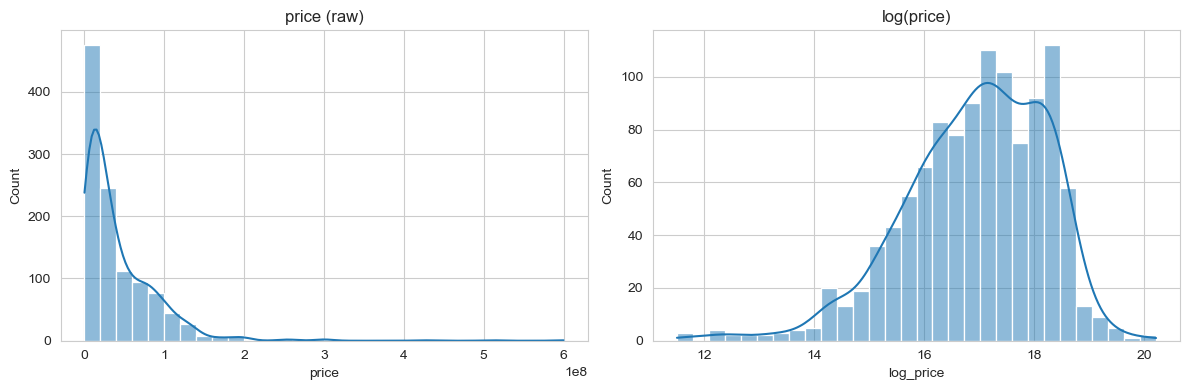

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['price'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('price (raw)')
sns.histplot(df['log_price'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('log(price)')
plt.tight_layout()
plt.show()

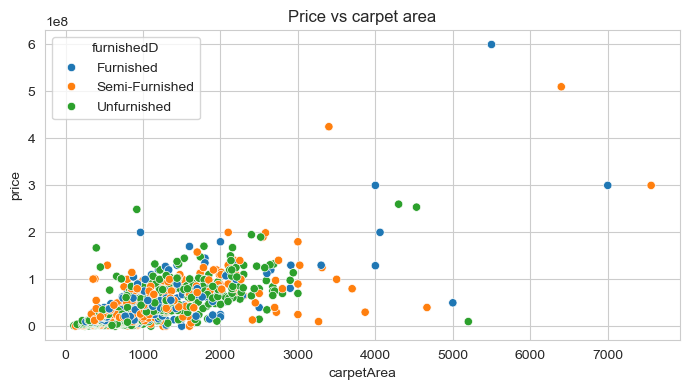

In [27]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(data=df, x='carpetArea', y='price', hue='furnishedD', ax=ax)
ax.set_title('Price vs carpet area')
plt.tight_layout()
plt.show()

### Locality comparison

Restricted to localities with a minimum sample size, otherwise single-listing localities get ranked as if they were as reliable as a 40+ listing locality.

265 unique localities across 1150 rows
151 localities have exactly 1 listing


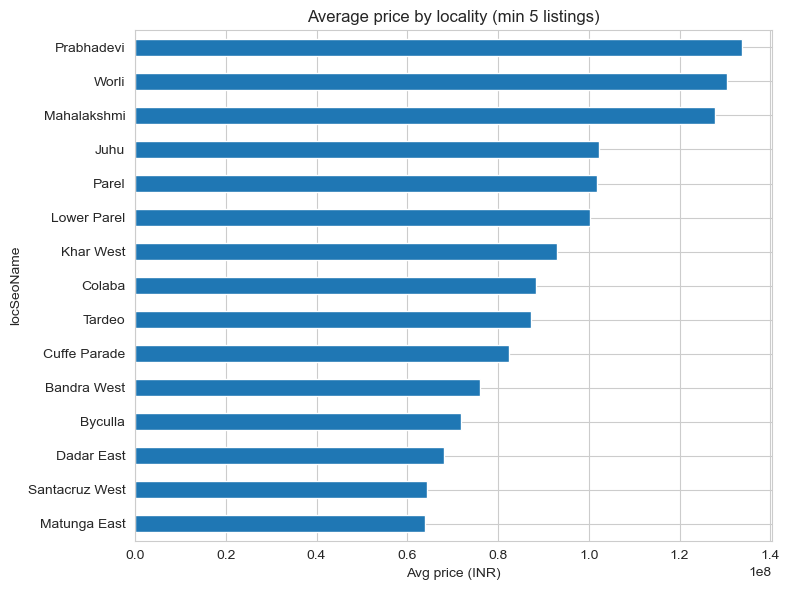

In [28]:
MIN_LISTINGS = 5

locality_counts = df['locSeoName'].value_counts()
print(f"{df['locSeoName'].nunique()} unique localities across {len(df)} rows")
print(f"{(locality_counts == 1).sum()} localities have exactly 1 listing")

reliable_localities = locality_counts[locality_counts >= MIN_LISTINGS].index
locality_price = (
    df[df['locSeoName'].isin(reliable_localities)]
    .groupby('locSeoName')['price']
    .agg(['mean', 'median', 'count'])
    .sort_values('mean', ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 6))
locality_price['mean'].head(15).plot(kind='barh', ax=ax)
ax.set_title(f'Average price by locality (min {MIN_LISTINGS} listings)')
ax.set_xlabel('Avg price (INR)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

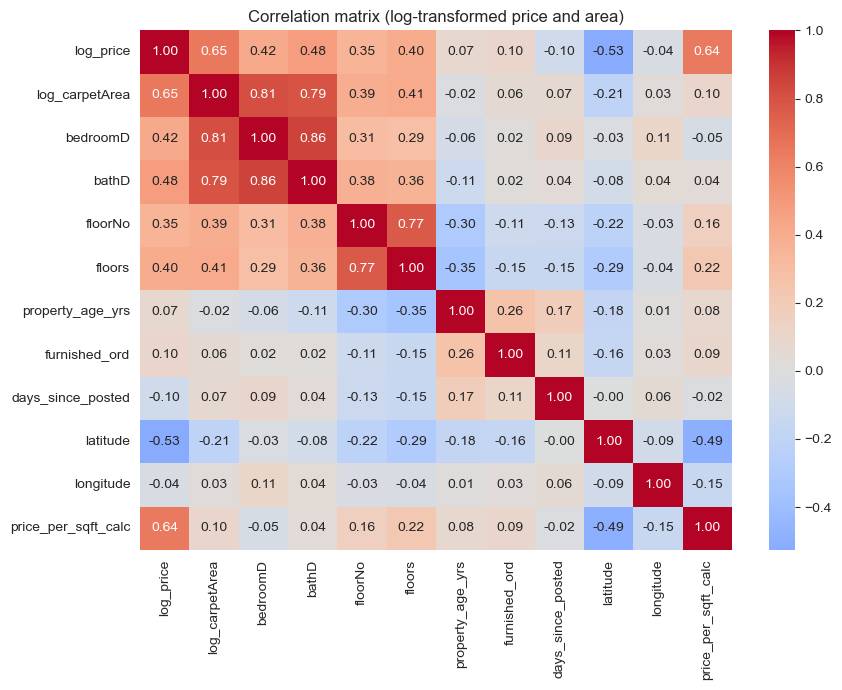

In [29]:
numeric_cols = ['log_price', 'log_carpetArea', 'bedroomD', 'bathD', 'floorNo', 'floors',
                 'property_age_yrs', 'furnished_ord', 'days_since_posted',
                 'latitude', 'longitude', 'price_per_sqft_calc']

corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation matrix (log-transformed price and area)')
plt.tight_layout()
plt.show()

Locality can't go into a numeric correlation matrix directly, target encoding it (mean log price per locality) to see how much of the price story is geography versus the physical unit itself.

In [30]:
df['locality_avg_log_price'] = df.groupby('locSeoName')['log_price'].transform('mean')

corr_with_locality = df[numeric_cols + ['locality_avg_log_price']].corr()['log_price'].sort_values(ascending=False)
corr_with_locality

log_price                 1.000000
locality_avg_log_price    0.796950
log_carpetArea            0.651260
price_per_sqft_calc       0.640651
bathD                     0.480904
bedroomD                  0.420020
floors                    0.400563
floorNo                   0.352031
furnished_ord             0.098664
property_age_yrs          0.073739
longitude                -0.041637
days_since_posted        -0.098224
latitude                 -0.525836
Name: log_price, dtype: float64

## 9. Baseline modeling

With contamination removed and duplicates dropped, this dataset supports a first modeling pass. Linear regression as a benchmark, then a Random Forest for feature importance, run twice, with and without the locality encoding, since that feature is derived from price itself and will otherwise dominate the result without saying much.

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model_df = df.dropna(subset=['log_price', 'log_carpetArea', 'bedroomD', 'bathD',
                              'floorNo', 'property_age_yrs', 'locality_avg_log_price']).copy()
print(f"{len(model_df)} rows usable for modeling (from {len(df)})")

features = ['log_carpetArea', 'bedroomD', 'bathD', 'floorNo', 'property_age_yrs', 'locality_avg_log_price']
X = model_df[features]
y = model_df['log_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

644 rows usable for modeling (from 1150)


In [32]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

print("Linear regression (baseline, with locality)")
print("MAE (log scale):", round(mean_absolute_error(y_test, lr_preds), 4))
print("R2:", round(r2_score(y_test, lr_preds), 4))
pd.Series(lr.coef_, index=features).sort_values(key=abs, ascending=False)

Linear regression (baseline, with locality)
MAE (log scale): 0.3304
R2: 0.7535


locality_avg_log_price    0.819098
log_carpetArea            0.546141
bathD                     0.043244
bedroomD                  0.019501
property_age_yrs          0.006283
floorNo                   0.002689
dtype: float64

In [33]:
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("Random Forest (with locality)")
print("MAE (log scale):", round(mean_absolute_error(y_test, rf_preds), 4))
print("R2:", round(r2_score(y_test, rf_preds), 4))
importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
importance

Random Forest (with locality)
MAE (log scale): 0.3537
R2: 0.7107


locality_avg_log_price    0.663055
log_carpetArea            0.233192
floorNo                   0.050342
property_age_yrs          0.020068
bedroomD                  0.018160
bathD                     0.015183
dtype: float64

In [34]:
features_no_leak = ['log_carpetArea', 'bedroomD', 'bathD', 'floorNo', 'property_age_yrs']
X2 = model_df[features_no_leak]
y2 = model_df['log_price']
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

rf2 = RandomForestRegressor(n_estimators=300, random_state=42)
rf2.fit(X2_train, y2_train)
rf2_preds = rf2.predict(X2_test)

print("Random Forest (no locality feature)")
print("MAE (log scale):", round(mean_absolute_error(y2_test, rf2_preds), 4))
print("R2:", round(r2_score(y2_test, rf2_preds), 4))
importance2 = pd.Series(rf2.feature_importances_, index=features_no_leak).sort_values(ascending=False)
importance2

Random Forest (no locality feature)
MAE (log scale): 0.5845
R2: 0.5089


log_carpetArea      0.632072
floorNo             0.176239
property_age_yrs    0.101118
bedroomD            0.052984
bathD               0.037588
dtype: float64

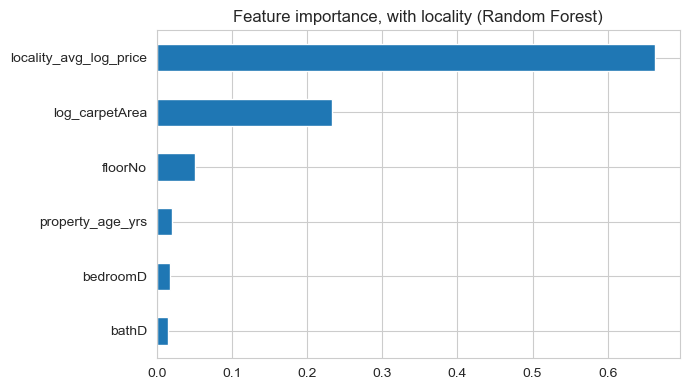

In [35]:
fig, ax = plt.subplots(figsize=(7, 4))
importance.plot(kind='barh', ax=ax)
ax.set_title('Feature importance, with locality (Random Forest)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

The gap between the two R2 scores is the actual finding: location explains far more of price than any physical attribute of the unit itself. That's expected for Mumbai real estate, not a modeling artifact, but don't quote the locality-included R2 as a clean predictive score since that feature is partly derived from the target.

## 10. Summary

**Fixed in this pass:**
- Price contamination, three layers, since one check alone kept missing cases: (1) `price` vs `sqFtPrice x carpetArea` ratio, (2) an absolute ₹200 Cr ceiling applied to every row, catching cases where `price` and `sqFtPrice` were inflated together and stayed self-consistent, and (3) a standalone `sqFtPrice` ceiling, since a few rows passed both price checks while still sitting at ₹1.5 to 2 lakh/sqft in suburbs like Jogeshwari and Mira Road, an order of magnitude beyond realistic. Ambiguous cases (₹1L to 2.5L/sqft, could be genuine ultra-luxury) are flagged in `review_high_psf` rather than dropped on a guess.
- Structural sanity check: a handful of listings had bedroom counts physically impossible for the stated carpet area (a '10BHK' in 90 sqft, a '4BHK' in 25 sqft), dropped outright. Merely tight layouts (50 to 100 sqft/bedroom) are flagged in `review_tight_layout`, kept, not dropped, since genuinely cramped older-building units exist in Mumbai.
- Duplicate re-listings dropped (title + price + floor match).
- `coveredArea`/`carpetArea` comma-formatted values fixed inline as part of cleaning instead of a bolted-on later fix.
- All markdown/print statements now reflect the actual row/column counts for whatever dataset is loaded, no more stale references.

**Still open:**
- `carpetArea` missing on a meaningful share of rows, worth checking if it can be backed out from `coveredArea` with a typical loading factor.
- Several contaminated price rows were 'New Property' project listings, worth checking whether the scraper occasionally picks up a project-level aggregate value instead of a per-unit price for certain page templates.
- `review_high_psf` and `review_tight_layout` flags need an actual human look before the dashboard treats them as trustworthy either way.
- Locality target encoding uses a raw group mean, smoothing small-sample localities toward the city average would reduce overfitting risk before this feeds a dashboard predictor.

## Save cleaned dataset

In [36]:
df.to_csv("cleaned_dataset_final.csv", index=False)
print(f"Saved cleaned_dataset_final.csv -> {df.shape[0]} rows, {df.shape[1]} cols")

Saved cleaned_dataset_final.csv -> 1150 rows, 42 cols
